# 06 — Entraînement du surrogate model

Objectif : entraîner un modèle LightGBM qui prédit le niveau de bruit (dB)
à partir des **features de morphologie urbaine du papier** (notebook 04).

C'est notre extension du papier : eux montrent que la morphologie est corrélée au SPL,
nous on entraîne un modèle prédictif dessus.

**Input** : `data/processed/uganda/sunbird_morphology.parquet` (notebook 04)
**Output** : `outputs/models/surrogate_lgbm.pkl`

Ensuite ce modèle sera calibré sur nos mesures Hanoï (notebook 07).

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

df = pd.read_parquet('../data/processed/uganda/sunbird_morphology.parquet')
# format='ISO8601' : les timestamps Sunbird mélangent avec/sans microsecondes
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df['hour'] = df['timestamp'].dt.hour
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
print(f'{len(df)} exemples chargés')
df.head()

955 exemples chargés


,noise_measurement,latitude,longitude,altitude,accuracy,class,class_id,region,timestamp,submitter_id,hour,day_of_week,building_density_km2,road_density_km_km2,intersection_count,dist_road_m,is_weekend
0,48.0,0.102457,32.527038,1172.800049,3.90,unclassified,19,Entebbe,2023-04-19 14:50:23.736000+00:00,18,14,Wednesday,152.081390,33.869130,30,5.647144,0
1,46.0,0.067772,32.474533,1159.300000,4.70,unclassified,19,Entebbe,2023-04-19 07:50:43.362000+00:00,22,7,Wednesday,841.752810,48.432381,25,1.337989,0
2,25.0,0.086771,32.494641,1154.300000,4.95,unclassified,19,Entebbe,2023-04-12 21:38:27.407000+00:00,20,21,Wednesday,1375.806064,30.201721,16,3.782253,0
3,31.0,0.082354,32.515020,1166.700073,3.90,unclassified,19,Entebbe,2023-04-13 17:18:09.238000+00:00,20,17,Thursday,1435.931264,31.725031,19,2.704571,0
4,57.0,0.085783,32.474530,1203.600000,4.82,unclassified,19,Entebbe,2023-05-11 09:30:40.453000+00:00,24,9,Thursday,3126.510438,35.762731,29,9.574114,0


In [2]:
# Features = les métriques de morphologie du papier + temps
FEATURES = ['building_density_km2', 'road_density_km_km2', 'intersection_count',
            'dist_road_m', 'hour', 'is_weekend']
TARGET   = 'noise_measurement'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 764 | Test: 191


In [3]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f} dB')
print(f'RMSE : {rmse:.2f} dB')
print(f'R²   : {r2:.3f}')

[100]	valid_0's l2: 103.463
MAE  : 8.17 dB
RMSE : 10.15 dB
R²   : 0.250


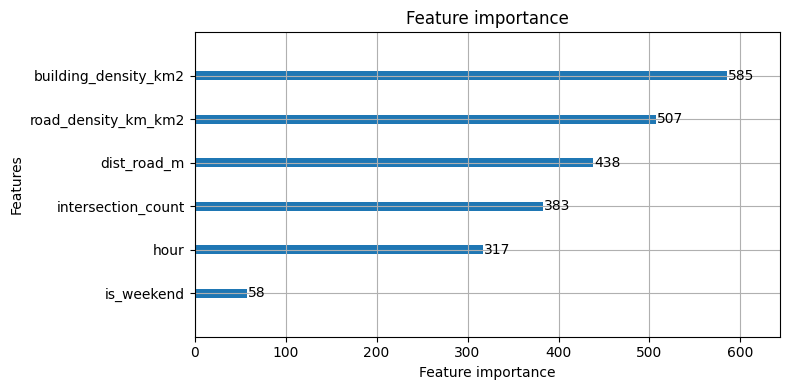

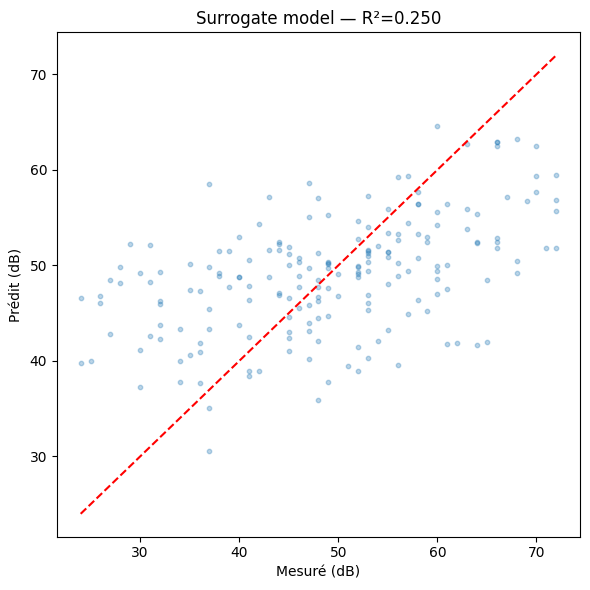

In [4]:
# Importance des features
lgb.plot_importance(model, figsize=(8, 4), title='Feature importance')
plt.tight_layout()
plt.savefig('../outputs/sunbird/feature_importance.png', dpi=150)
plt.show()

# Prédit vs réel
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax.set_xlabel('Mesuré (dB)')
ax.set_ylabel('Prédit (dB)')
ax.set_title(f'Surrogate model — R²={r2:.3f}')
plt.tight_layout()
plt.savefig('../outputs/sunbird/pred_vs_real.png', dpi=150)
plt.show()

In [5]:
# Sauvegarde le modèle pré-entraîné
joblib.dump(model, '../outputs/models/surrogate_lgbm.pkl')
print('Modèle sauvegardé dans outputs/models/surrogate_lgbm.pkl')

Modèle sauvegardé dans outputs/models/surrogate_lgbm.pkl
